# 金融机器学习防泄漏：Purged K-Fold Cross-Validation

在传统的机器学习领域，标准交叉验证（Standard K-Fold）是评估模型的基石。
但在金融领域直接使用标准 K-Fold 是灾难性的。它会导致严重的数据泄漏（Data Leakage），产生在回测中稳赚不赔，实盘中一败涂地的模型。

量化巨擘 Marcos Lopez de Prado 提出了 **Purged K-Fold** 框架。

## 1. 金融时间序列交叉验证的死穴

*   **窥视未来 (序列相关性泄漏)**：如果用 2019 年（测试集）的数据测试，而用 2018 以及 **2020**（训练集）训练。金融资产短时间内具有高度动量残余，2020年初的价格早包含了2019的结论反馈。
*   **标签重叠 (物理泄漏)**：假设预测标签是“未来5日收益率”。如果测试集在日历上紧挨着训练集的开头，那么测试集尾部样本计算“未来5日收益”时用到的未来价格，实际上也是训练集开头样本的“入场前置价格特征”！这就出现了致命的物理交叉。

## 2. 解决方案：Purged K-Fold 净化交叉验证

*   **Purging (剔除机制)**: 如果测试集的任何标签观察窗口，与训练集的特征周期发生物理重合，必须强制从训练集中剔除（Purge）该样本。
*   **Embargo (禁闭机制)**: 测试集结束后的那段时间数据由于动量惯性依然包含了测试集的信息。在测试区间之后的那块训练集中，必须额外定义一段禁闭期（Embargo period）进行隔离。


In [1]:
def conceptual_purged_kfold(total_samples, num_folds=5, purge_window=3, embargo=5):
    """
    这是对 Purged K-Fold 的原理演示（为了直观理解，并非 mlfinlab 等严格包源码）。
    """
    test_size = total_samples // num_folds
    print(f"总样本: {total_samples}, 折数: {num_folds}, 标签计算跨度(Purge): {purge_window}, 禁闭期(Embargo): {embargo}\n")
    
    for fold in range(num_folds):
        test_start = fold * test_size
        test_end = test_start + test_size
        
        # Purging 逻辑: 训练集不能包含距离测试集太近（可能偷看未来）的前置样本
        # Embargo 逻辑: 训练集不能包含紧贴在测试集后方、具有强烈动量遗留的后置样本
        train_indices = [i for i in range(total_samples) 
                         if i < (test_start - purge_window) or i > (test_end + embargo)]
        
        print(f"---------- Fold {fold} ----------")
        print(f"[验证 测试区]: {test_start} 到 {test_end}")
        print(f"[安全 训练区]: 包含 {len(train_indices)} 个样本, 剔除了 {(total_samples - len(train_indices) - test_size)} 个污染样本")

# 运行演示
conceptual_purged_kfold(100, num_folds=4)


总样本: 100, 折数: 4, 标签计算跨度(Purge): 3, 禁闭期(Embargo): 5

---------- Fold 0 ----------
[验证 测试区]: 0 到 25
[安全 训练区]: 包含 69 个样本, 剔除了 6 个污染样本
---------- Fold 1 ----------
[验证 测试区]: 25 到 50
[安全 训练区]: 包含 66 个样本, 剔除了 9 个污染样本
---------- Fold 2 ----------
[验证 测试区]: 50 到 75
[安全 训练区]: 包含 66 个样本, 剔除了 9 个污染样本
---------- Fold 3 ----------
[验证 测试区]: 75 到 100
[安全 训练区]: 包含 72 个样本, 剔除了 3 个污染样本


金融机器学习的第一原则：**永远不要相信那些不带剔除机制产生的诱人 R^2 和准确率。**


## 3. 实战可视化：Standard K-Fold vs Purged K-Fold

为了更直观地理解，我们将用强大的可视化图表对比普通 K-Fold 和 Purged K-Fold 在划分时间序列上的残酷区别。


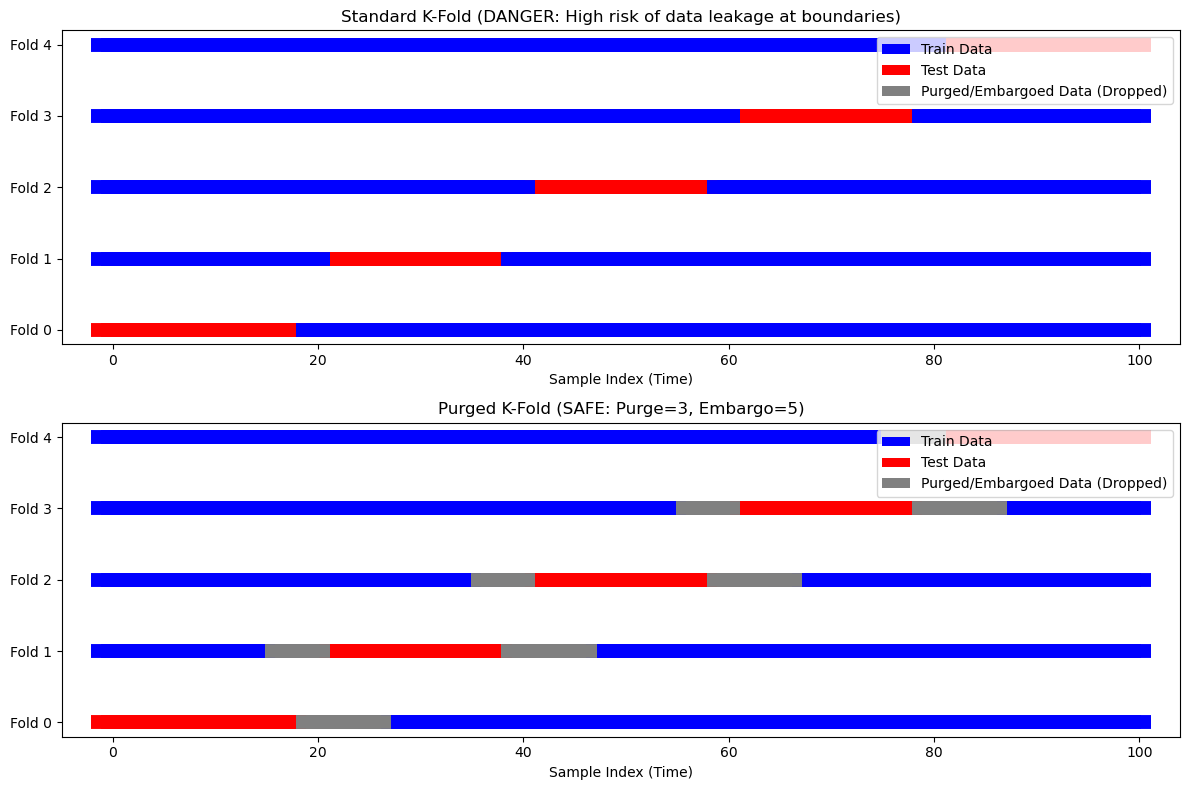

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# 定义一个可视化函数来对比 K-Fold 划分
def plot_cv_indices(cv_splits, num_samples, ax, lw=10, purge=0, embargo=0):
    """根据输入的 (train_idx, test_idx) 生成水平条形图"""
    for ii, (tr, tt) in enumerate(cv_splits):
        # 画测试集 (红色)
        ax.scatter(tt, [ii] * len(tt), marker='_', s=1000, lw=lw, c='red')
        # 画训练集 (蓝色)
        ax.scatter(tr, [ii] * len(tr), marker='_', s=1000, lw=lw, c='blue')
        
        # 标出被 Purge 和 Embargo 剔除的灰色区域
        all_indices = set(range(num_samples))
        used_indices = set(tr) | set(tt)
        purged_indices = list(all_indices - used_indices)
        if purged_indices:
            ax.scatter(purged_indices, [ii] * len(purged_indices), marker='_', s=1000, lw=lw, c='gray')

    ax.set_yticks(np.arange(len(cv_splits)))
    ax.set_yticklabels([f'Fold {i}' for i in range(len(cv_splits))])
    ax.set_xlabel('Sample Index (Time)')
    
    legend_elements = [
        Patch(facecolor='blue', label='Train Data'),
        Patch(facecolor='red', label='Test Data'),
        Patch(facecolor='gray', label='Purged/Embargoed Data (Dropped)')
    ]
    ax.legend(handles=legend_elements, loc='best')

# 模拟生成切分数据
num_samples = 100
num_folds = 5

# 1. Standard K-Fold (没有剔除，存在重度泄漏)
standard_splits = []
test_size = num_samples // num_folds
for i in range(num_folds):
    test_start = i * test_size
    test_end = test_start + test_size
    test_idx = list(range(test_start, test_end))
    train_idx = list(range(0, test_start)) + list(range(test_end, num_samples))
    standard_splits.append((train_idx, test_idx))
    
# 2. Purged K-Fold (严格剔除边界)
purge_window = 3
embargo_window = 5
purged_splits = []
for i in range(num_folds):
    test_start = i * test_size
    test_end = test_start + test_size
    test_idx = list(range(test_start, test_end))
    
    train_idx = [j for j in range(num_samples) 
                 if j < (test_start - purge_window) or j > (test_end + embargo_window)]
    purged_splits.append((train_idx, test_idx))

# 绘图对比
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_cv_indices(standard_splits, num_samples, ax1)
ax1.set_title("Standard K-Fold (DANGER: High risk of data leakage at boundaries)")

plot_cv_indices(purged_splits, num_samples, ax2, purge=purge_window, embargo=embargo_window)
ax2.set_title(f"Purged K-Fold (SAFE: Purge={purge_window}, Embargo={embargo_window})")

plt.tight_layout()
plt.show()


上面的图表揭示了真相：
*   **上图 (Standard K-Fold)** 训练集和测试集无缝衔接。在金融中，边界处的数据完全混合了未来的信息，使得你的模型仿佛“开卷考试”。
*   **下图 (Purged K-Fold)** 灰色的断带如同防火墙。**Purge（测试集左侧灰色）** 阻止了带有跨越边界标签的训练样本进入训练；**Embargo（测试集右侧灰色）** 阻止了紧接着测试集发生的具有强惯性相关性的样本被模型提取特征。

## 本章结语

如果你在金融预测中使用了随机森林 (Random Forest)、XGBoost 或者由深度学习构建的 Transformer，并且用普通的 `sklearn.model_selection.KFold` 或粗糙的总盘切分拿到了惊人的“准确率 (Accuracy)” 和 “夏普比率 (Sharpe Ratio)”。

请立刻停下来！
你 99% 只是完美地过拟合了被泄漏的未来数据。实盘上线的那一天，就是策略开始崩溃回撤的时候。

**Purged K-Fold 与组合交叉验证 (CPCV)** 是区分“数据挖掘游戏”和“严肃量化机构实盘”最重要的数据工程准则。在构建任何选股机器学习模型时，务必自己实现或通过第三方量化库（如 `mlfinlab`）引入具有严格 Purge 和 Embargo 机制的测试流程。


## 🎯 练习

1. 使用 `mlfinlab` 库的 `PurgedKFold` 类，对第 3 章的深度学习模型进行净化交叉验证，比较 IS 和 OOS 夏普。
2. 将 `embargo_window` 从 5 调整到 10 和 20，观察被剔除样本数量的变化和对验证集大小的影响。
3. 查阅 CPCV（Combinatorial Purged Cross-Validation）:它相比基础 Purged K-Fold 改进了什么？

---
**下一节** → `06_advanced_portfolio_optimization.ipynb`
